In [1]:
import numpy as np
from skimage.draw import circle_perimeter
from skimage.filters import gaussian
from skimage.segmentation import active_contour

import matplotlib.pyplot as plt

plt.rcParams['image.cmap'] = 'gray'

Create and smooth image:

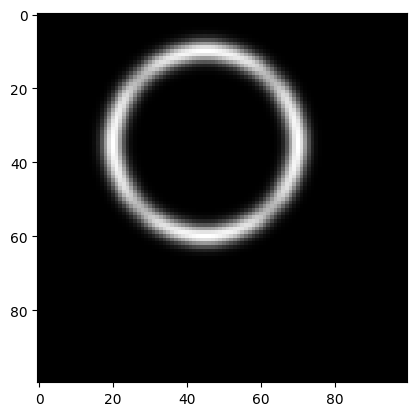

In [2]:
img = np.zeros((100, 100))
rr, cc = circle_perimeter(35, 45, 25)
img[rr, cc] = 1
img = gaussian(img, sigma=2, preserve_range=False)
plt.imshow(img)

Initialize spline:

In [3]:
s = np.linspace(0, 2*np.pi, 100)
init = 50 * np.array([np.sin(s), np.cos(s)]).T + 50
init

array([[5.00000000e+01, 1.00000000e+02],
       [5.31711960e+01, 9.98993338e+01],
       [5.63296227e+01, 9.95977406e+01],
       [5.94625622e+01, 9.90964349e+01],
       [6.25573994e+01, 9.83974351e+01],
       [6.56016723e+01, 9.75035559e+01],
       [6.85831228e+01, 9.64183967e+01],
       [7.14897456e+01, 9.51463269e+01],
       [7.43098368e+01, 9.36924689e+01],
       [7.70320409e+01, 9.20626766e+01],
       [7.96453965e+01, 9.02635129e+01],
       [8.21393805e+01, 8.83022222e+01],
       [8.45039506e+01, 8.61867019e+01],
       [8.67295854e+01, 8.39254706e+01],
       [8.88073232e+01, 8.15276334e+01],
       [9.07287976e+01, 7.90028455e+01],
       [9.24862715e+01, 7.63612734e+01],
       [9.40726682e+01, 7.36135537e+01],
       [9.54815998e+01, 7.07707507e+01],
       [9.67073930e+01, 6.78443111e+01],
       [9.77451121e+01, 6.48460188e+01],
       [9.85905784e+01, 6.17879468e+01],
       [9.92403877e+01, 5.86824089e+01],
       [9.96919232e+01, 5.55419100e+01],
       [9.994336

Fit spline to image:

In [4]:
snake = active_contour(img, init, w_edge=0, w_line=1)  # doctest: +SKIP
snake

array([[41.4856239 , 69.51337969],
       [42.71913854, 69.14733363],
       [44.02352213, 68.69285432],
       [45.3970855 , 68.13593329],
       [46.8270123 , 67.46036231],
       [48.3034268 , 66.63588544],
       [49.81958479, 65.62041263],
       [51.35449525, 64.3982713 ],
       [52.85490922, 63.01109916],
       [54.25226408, 61.53205998],
       [55.47593217, 60.03368043],
       [56.48437967, 58.57379465],
       [57.29634648, 57.17816059],
       [57.95427847, 55.85238957],
       [58.48168459, 54.60328063],
       [58.8912655 , 53.44023775],
       [59.25197963, 52.36697926],
       [59.54686734, 51.37727379],
       [59.76540179, 50.46050147],
       [59.97122024, 49.61029731],
       [60.09963701, 48.82880419],
       [60.21661535, 48.12123338],
       [60.31708406, 47.49235308],
       [60.35622448, 46.94133961],
       [60.40164534, 46.45990385],
       [60.43918236, 46.03386187],
       [60.4592418 , 45.64450178],
       [60.47019339, 45.26989632],
       [60.47336431,

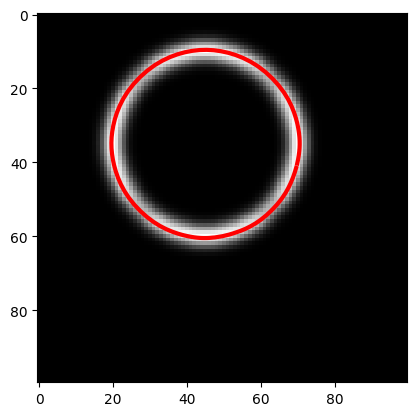

In [5]:
plt.imshow(img)
# Second column is column coordinate, first is row coordinate.
plt.plot(snake[:, 1], snake[:, 0], '-r', lw=3);

In [6]:
# Row center is 35, col center is 45
dist = np.sqrt((35-snake[:, 0])**2 + (45-snake[:, 1])**2)  # doctest: +SKIP
dist

array([25.35683539, 25.35111085, 25.35301358, 25.364755  , 25.3839732 ,
       25.39867523, 25.39333594, 25.37247415, 25.36133822, 25.37634094,
       25.40227048, 25.41311612, 25.40540615, 25.39041668, 25.36951931,
       25.33831447, 25.34622061, 25.3617491 , 25.36024847, 25.39324087,
       25.38998857, 25.40904932, 25.43946872, 25.43043293, 25.44356314,
       25.46018204, 25.46739829, 25.47162333, 25.47361946, 25.47860843,
       25.48256517, 25.4838237 , 25.4796133 , 25.46692985, 25.44804971,
       25.42912855, 25.41529456, 25.40854753, 25.40514866, 25.40077371,
       25.39287171, 25.37303867, 25.3410319 , 25.31959993, 25.32889455,
       25.35666079, 25.37681277, 25.38365606, 25.38582399, 25.38909571,
       25.3990079 , 25.41835981, 25.44123009, 25.4584926 , 25.46608115,
       25.46340241, 25.45113776, 25.43484804, 25.42308419, 25.41550541,
       25.40437949, 25.38551159, 25.35614476, 25.3193719 , 25.29913507,
       25.31201225, 25.34012102, 25.36321904, 25.38130604, 25.39

In [7]:
np.all(np.round(dist) == 25)
# Recorded as 25

np.True_